In [1]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import os
print('Data source import complete. The Down Syndrome dataset will be loaded from /kaggle/input/downsyndrome-dataset/')


Data source import complete. The Down Syndrome dataset will be loaded from /kaggle/input/downsyndrome-dataset/


# 1. Environment Setup
All required libraries are pre-installed on Kaggle (transformers, datasets, evaluate, etc.).
Run the cell below only if something is missing.

In [2]:
import subprocess, sys

# On Kaggle most packages are pre-installed.
# Only install if something is missing (rare).
packages = ["transformers", "datasets", "evaluate", "scikit-learn", "timm",
            "seaborn", "matplotlib", "pandas"]
for pkg in packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

print("All packages available.")



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 2.7 MB/s eta 0:00:00
All packages available.


# 2. Force Single GPU & Check CUDA
Make sure using single GPU

In [3]:
import os

# Pin to GPU 0 only — avoids slow DataParallel on small downsyndrome dataset
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

import torch
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"Using GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


CUDA available: True
Using GPU: Tesla T4
VRAM: 15.6 GB


# 3. Prepare Dataset

In [4]:
import os, shutil, random
from pathlib import Path
from collections import defaultdict
from datasets import load_dataset, concatenate_datasets, DatasetDict

# Global constants
DATA_DIR = "/kaggle/working/dataset"
MODEL_CACHE_DIR = "/kaggle/working/models"
SEED = 31
random.seed(SEED)
os.makedirs(MODEL_CACHE_DIR, exist_ok=True)

processed_dir = Path(DATA_DIR)

# 1. ACQUIRE DATASET FILES
if processed_dir.exists() and any(processed_dir.iterdir()):
    print('Dataset already prepared at /kaggle/working/dataset -- skipping organization.')
else:
    print('Searching recursively for Down Syndrome dataset image files under /kaggle/input...')
    IMAGE_EXTS = {'.jpg', '.jpeg', '.png', '.bmp', '.tiff', '.webp'}
    all_images = []

    input_base = Path('/kaggle/input')
    if input_base.exists():
        for root, dirs, files in os.walk(input_base):
            # Only search inside paths that belong to the downsyndrome dataset
            if 'downsyndrome' not in root.lower():
                continue
            for file in files:
                p = Path(root) / file
                if p.suffix.lower() in IMAGE_EXTS:
                    all_images.append(p)

    print(f'Total images found recursively: {len(all_images)}')

    if len(all_images) == 0:
        raise FileNotFoundError("Could not find any image files for 'downsyndrome' under /kaggle/input. "
                                "Please ensure you have added the 'downsyndrome-dataset' to your notebook inputs.")

    # Group images by class (the immediate parent folder name, e.g. 'downSyndrome', 'healty')
    class_to_images = defaultdict(list)
    for img in all_images:
        class_to_images[img.parent.name].append(img)
    print(f'Classes found dynamically: {sorted(class_to_images.keys())}')

    # Copy images to processed_dir / 'train' / class_name
    (processed_dir / 'train').mkdir(parents=True, exist_ok=True)
    for class_name, imgs in class_to_images.items():
        dest = processed_dir / 'train' / class_name
        dest.mkdir(parents=True, exist_ok=True)
        for img in imgs:
            shutil.copy2(img, dest / img.name)
    print('Data copy and organization complete.')

# 2. BUILD MAPPINGS
def build_label_mappings():
    train_path = Path(DATA_DIR) / "train"
    if not train_path.exists():
        return {0: "Normal", 1: "Downsyndrome"}, {"Normal": 0, "Downsyndrome": 1}
    class_names = sorted(d.name for d in train_path.iterdir() if d.is_dir())
    id2label = {idx: name for idx, name in enumerate(class_names)}
    label2id = {name: idx for idx, name in id2label.items()}
    return id2label, label2id

id2label, label2id = build_label_mappings()
num_labels = len(id2label)
print(f"Classes: {id2label}")

# 3. LOAD AND 80/10/10 SPLIT
def load_splits():
    ds = load_dataset("imagefolder", data_dir=DATA_DIR)
    splits = [ds[s] for s in ds.keys()]
    full_ds = concatenate_datasets(splits)

    # 80/10/10 Split
    train_test = full_ds.train_test_split(test_size=0.2, seed=SEED)
    val_test = train_test['test'].train_test_split(test_size=0.5, seed=SEED)

    return DatasetDict({
        'train': train_test['train'],
        'validation': val_test['train'],
        'test': val_test['test']
    })

dataset = load_splits()
print(dataset)


Searching recursively for Down Syndrome dataset image files under /kaggle/input...
Total images found recursively: 2999
Classes found dynamically: ['downSyndrome', 'healty']
Data copy and organization complete.
Classes: {0: 'downSyndrome', 1: 'healty'}


Resolving data files:   0%|          | 0/2999 [00:00<?, ?it/s]

Generating train split: 0 examples [00:00, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 2399
    })
    validation: Dataset({
        features: ['image', 'label'],
        num_rows: 300
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 300
    })
})


# 4. Define Training Logic
We define a reusable function to train any given CNN+CBAM model using Hugging Face `Trainer`. Pre-trained weights will be permanently cached to `./models`.


In [5]:
import numpy as np
import evaluate
import torch
import torch.nn as nn
import torch.nn.functional as F
import os
import timm
from pathlib import Path
from PIL import Image, ImageOps
from torchvision import transforms
from transformers import Trainer, TrainingArguments, EarlyStoppingCallback, set_seed

class PadToSquare:
    def __call__(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        if w == h: return img
        side = max(w, h)
        pad_w = (side - w) // 2
        pad_h = (side - h) // 2
        padding = (pad_w, pad_h, side - w - pad_w, side - h - pad_h)
        return ImageOps.expand(img, border=padding, fill=0)

class ImageTransform:
    def __init__(self, target_size=(224, 224), mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225], is_train=False):
        if is_train:
            self.transform = transforms.Compose([
                PadToSquare(),
                transforms.Resize(target_size, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.RandomHorizontalFlip(p=0.5),
                transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])
        else:
            self.transform = transforms.Compose([
                PadToSquare(),
                transforms.Resize(target_size, interpolation=transforms.InterpolationMode.BICUBIC),
                transforms.ToTensor(),
                transforms.Normalize(mean=mean, std=std),
            ])

    def __call__(self, batch):
        pixel_values = []
        for img in batch["image"]:
            if isinstance(img, Image.Image):
                if img.mode != "RGB":
                    img = img.convert("RGB")
                pixel_values.append(self.transform(img))
            else:
                raise TypeError(f"Expected PIL Image, got {type(img)}")
        batch["pixel_values"] = pixel_values
        return batch

def collate_fn(examples):
    pixel_values = torch.stack([ex["pixel_values"] for ex in examples])
    labels = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return {"pixel_values": pixel_values, "labels": labels}

def build_compute_metrics(num_labels):
    accuracy_metric  = evaluate.load("accuracy")
    f1_metric        = evaluate.load("f1")
    precision_metric = evaluate.load("precision")
    recall_metric    = evaluate.load("recall")

    def compute_metrics(eval_pred):
        logits, labels = eval_pred
        predictions = np.argmax(logits, axis=-1)
        avg = "macro" if num_labels > 2 else "binary"
        acc  = accuracy_metric.compute(predictions=predictions, references=labels)
        f1   = f1_metric.compute(predictions=predictions, references=labels, average=avg)
        prec = precision_metric.compute(predictions=predictions, references=labels, average=avg, zero_division=0)
        rec  = recall_metric.compute(predictions=predictions, references=labels, average=avg, zero_division=0)
        return {
            "accuracy":  acc["accuracy"],
            f"f1_{avg}": f1["f1"],
            f"precision_{avg}": prec["precision"],
            f"recall_{avg}":    rec["recall"],
        }
    return compute_metrics

class QuietEarlyStoppingCallback(EarlyStoppingCallback):
    def on_evaluate(self, args, state, control, metrics, **kwargs):
        metric_to_check = args.metric_for_best_model
        if not metric_to_check.startswith("eval_"):
            metric_to_check = f"eval_{metric_to_check}"
        if metric_to_check not in metrics:
            return
        super().on_evaluate(args, state, control, metrics, **kwargs)

# CBAM Implementation
class CNNWithoutCBAM(nn.Module):
    def __init__(self, model_name, num_labels, pretrained=True):
        super(CNNWithoutCBAM, self).__init__()
        self.base_model = timm.create_model(model_name, pretrained=pretrained, num_classes=0)
        num_features = self.base_model.num_features

        self.classifier = nn.Linear(num_features, num_labels)

    def forward(self, pixel_values, labels=None):
        x = self.base_model.forward_features(pixel_values)

        x = F.adaptive_avg_pool2d(x, (1, 1)).flatten(1)
        logits = self.classifier(x)

        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss()
            loss = loss_fct(logits.view(-1, self.classifier.out_features), labels.view(-1))

        return {"loss": loss, "logits": logits}

def train_and_evaluate(model_name, train_batch_size, eval_batch_size, grad_accum, output_dir_base="/kaggle/working/outputs", num_epochs=100):
    print(f"\n{'='*50}\nStarting training for {model_name} (No Attention)\n{'='*50}")
    output_dir = f"{output_dir_base}/{model_name.replace('/', '_')}"

    model = CNNWithoutCBAM(model_name, num_labels, pretrained=True)

    target_size = (224, 224)
    if "384" in model_name:
        target_size = (384, 384)

    train_transform = ImageTransform(target_size=target_size, is_train=True)
    eval_transform  = ImageTransform(target_size=target_size, is_train=False)

    ds_copy = dataset.copy()
    ds_copy["train"].set_transform(train_transform)
    val_dataset = ds_copy["validation"]
    val_dataset.set_transform(eval_transform)
    test_dataset = ds_copy["test"]
    test_dataset.set_transform(eval_transform)

    training_args = TrainingArguments(
        output_dir=output_dir,
        eval_strategy="epoch",
        save_strategy="epoch",
        save_total_limit=1,
        save_only_model=True,
        load_best_model_at_end=True,
        metric_for_best_model="val_accuracy",
        greater_is_better=True,
        num_train_epochs=num_epochs,
        per_device_train_batch_size=train_batch_size,
        per_device_eval_batch_size=eval_batch_size,
        gradient_accumulation_steps=grad_accum,
        learning_rate=5e-5,
        lr_scheduler_type="cosine",
        warmup_ratio=0.1,
        weight_decay=0.01,
        fp16=torch.cuda.is_available(),
        remove_unused_columns=False,
        dataloader_num_workers=0,
        logging_steps=10,
        report_to=["tensorboard"],
        seed=SEED,
        data_seed=SEED,
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=ds_copy["train"],
        eval_dataset={"train": ds_copy["train"], "val": val_dataset},
        data_collator=collate_fn,
        compute_metrics=build_compute_metrics(num_labels),
        callbacks=[QuietEarlyStoppingCallback(early_stopping_patience=10)],
    )

    trainer.train()

    print(f"\nEvaluating {model_name} on Test Set...")
    test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")

    log_history = trainer.state.log_history

    import gc
    del model
    del trainer
    torch.cuda.empty_cache()
    gc.collect()

    return test_metrics, log_history

all_results = {}
all_histories = {}




# 5. Training Model

In [6]:
metrics_efficientnet_b0, history_efficientnet_b0 = train_and_evaluate(
    "efficientnet_b0", train_batch_size=32, eval_batch_size=64, grad_accum=1
)



Starting training for efficientnet_b0 (No Attention)


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


2026-06-01 15:28:17.880652: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1780327698.280635      58 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1780327698.403171      58 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1780327699.384282      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780327699.384325      58 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1780327699.384328      58 computation_placer.cc:177] computation placer alr

Epoch,Training Loss,Validation Loss,Train Loss,Train Accuracy,Train F1 Binary,Train Precision Binary,Train Recall Binary,Val Loss,Val Accuracy,Val F1 Binary,Val Precision Binary,Val Recall Binary
1,0.686349,No log,0.677590,0.577741,0.536808,0.600204,0.485525,0.682162,0.596667,0.437209,0.594937,0.345588
2,0.635755,No log,0.619671,0.718216,0.695221,0.764123,0.637717,0.622747,0.713333,0.622807,0.771739,0.522059
3,0.540623,No log,0.525114,0.812839,0.809017,0.832750,0.786600,0.516586,0.830000,0.798419,0.863248,0.742647
4,0.433513,No log,0.380725,0.868695,0.863459,0.907104,0.823821,0.372100,0.880000,0.863636,0.890625,0.838235
5,0.378130,No log,0.267484,0.902459,0.901182,0.920621,0.882548,0.283984,0.900000,0.887218,0.907692,0.867647
6,0.218776,No log,0.184639,0.937057,0.936847,0.947547,0.926385,0.226459,0.923333,0.915129,0.918519,0.911765
7,0.188328,No log,0.122728,0.966236,0.966404,0.969218,0.963606,0.197997,0.923333,0.913858,0.931298,0.897059
8,0.120750,No log,0.072512,0.980409,0.980666,0.975450,0.985939,0.179811,0.926667,0.920863,0.901408,0.941176
9,0.086911,No log,0.043488,0.989579,0.989665,0.989256,0.990074,0.160033,0.940000,0.934783,0.921429,0.948529
10,0.095438,No log,0.032603,0.990830,0.990856,0.995823,0.985939,0.174702,0.933333,0.925373,0.939394,0.911765


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in by


Evaluating efficientnet_b0 on Test Set...


# 6. Evaluation Graph


## 6.1 Result summary



Loading weights from ./outputs/efficientnet_b0/checkpoint-675...

CLASSIFICATION REPORT
              precision    recall  f1-score   support

downSyndrome     0.8954    0.9384    0.9164       146
      healty     0.9388    0.8961    0.9169       154

    accuracy                         0.9167       300
   macro avg     0.9171    0.9172    0.9167       300
weighted avg     0.9177    0.9167    0.9167       300



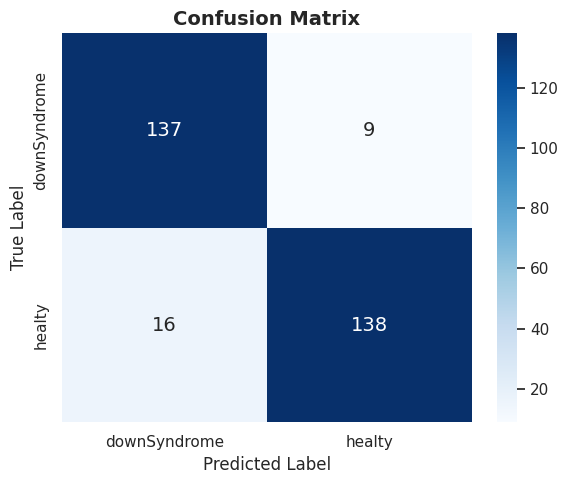

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import roc_curve, auc
import numpy as np
import torch
import os
from safetensors.torch import load_file
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

model_name = "EfficientNet (No Attention)"
base_name = "efficientnet_b0"
output_dir = "./outputs/efficientnet_b0"

history = history_efficientnet_b0
metrics = metrics_efficientnet_b0

# Extract Learning Curves
train_step_epochs, train_loss = [], []
train_eval_epochs, train_acc = [], []
eval_epochs, eval_loss, eval_acc = [], [], []

for log in history:
    if 'loss' in log and 'epoch' in log:
        train_step_epochs.append(log['epoch'])
        train_loss.append(log['loss'])

    val_loss_key = 'eval_val_loss' if 'eval_val_loss' in log else 'eval_loss' if 'eval_loss' in log else None
    if val_loss_key and 'epoch' in log:
        eval_epochs.append(log['epoch'])
        eval_loss.append(log[val_loss_key])
        val_acc_key = 'eval_val_accuracy' if 'eval_val_accuracy' in log else 'eval_accuracy' if 'eval_accuracy' in log else None
        if val_acc_key and val_acc_key in log:
            eval_acc.append(log[val_acc_key])

    if 'eval_train_accuracy' in log and 'epoch' in log:
        train_eval_epochs.append(log['epoch'])
        train_acc.append(log['eval_train_accuracy'])

sns.set_theme(style="whitegrid")

# Load best model for evaluation
checkpoints = [d for d in os.listdir(output_dir) if d.startswith("checkpoint-")] if os.path.exists(output_dir) else []
if not checkpoints:
    print(f"\nLoading weights from {output_dir}... No checkpoint found")
else:
    best_ckpt = os.path.join(output_dir, checkpoints[0])
    print(f"\nLoading weights from {best_ckpt}...")

    model = CNNWithoutCBAM(base_name, num_labels, pretrained=False)
    try:
        state_dict = load_file(os.path.join(best_ckpt, "model.safetensors"))
    except:
        state_dict = torch.load(os.path.join(best_ckpt, "pytorch_model.bin"), map_location="cpu")
    model.load_state_dict(state_dict)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    eval_dataset = dataset["test"]
    target_size = (224, 224)
    eval_dataset.set_transform(ImageTransform(target_size=target_size, is_train=False))

    y_true = []
    y_pred = []
    y_scores = []

    with torch.no_grad():
        for item in eval_dataset:
            pixel_values = item["pixel_values"].unsqueeze(0).to(device)
            labels = int(item["label"])
            outputs = model(pixel_values)
            logits = outputs["logits"]
            probs = torch.nn.functional.softmax(logits, dim=-1)

            pred = logits.argmax(-1).item()
            y_true.append(labels)
            y_pred.append(pred)
            y_scores.append(probs[0].cpu().numpy())

    class_names = list(label2id.keys())
    y_scores = np.array(y_scores)

    print("\n" + "="*60)
    print("CLASSIFICATION REPORT")
    print("="*60)
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4, output_dict=True)
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

    # Confusion Matrix
    plt.figure(figsize=(6, 5))
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names, annot_kws={"size": 14})
    plt.title("Confusion Matrix", fontsize=14, fontweight='bold')
    plt.ylabel('True Label', fontsize=12)
    plt.xlabel('Predicted Label', fontsize=12)
    plt.tight_layout()
    plt.show()

## 6.2 Loss Graph


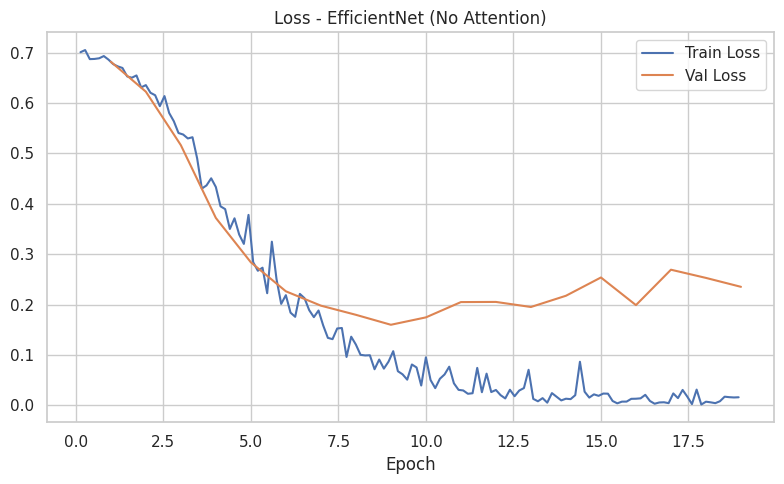

In [8]:
plt.figure(figsize=(8, 5))
if train_loss:
    plt.plot(train_step_epochs, train_loss, label="Train Loss", color='#4C72B0', linewidth=1.5)
if eval_loss:
    plt.plot(eval_epochs, eval_loss, label="Val Loss", color='#DD8452', linewidth=1.5)
plt.title(f'Loss - {model_name}')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## 6.3 Accuracy Graph


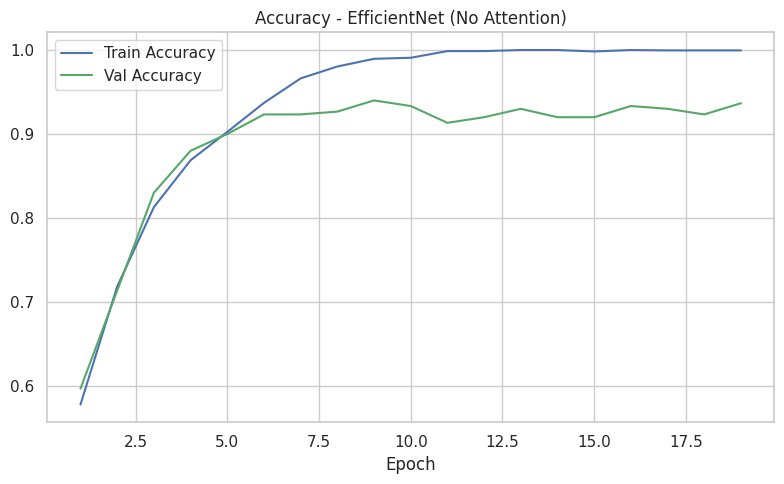

In [9]:
plt.figure(figsize=(8, 5))
if train_acc:
    plt.plot(train_eval_epochs, train_acc, label="Train Accuracy", color='#4C72B0', linewidth=1.5)
if eval_acc:
    plt.plot(eval_epochs, eval_acc, label="Val Accuracy", color='#55A868', linewidth=1.5)
plt.title(f'Accuracy - {model_name}')
plt.xlabel('Epoch')
plt.legend()
plt.tight_layout()
plt.show()

## 6.4 ROC Curve


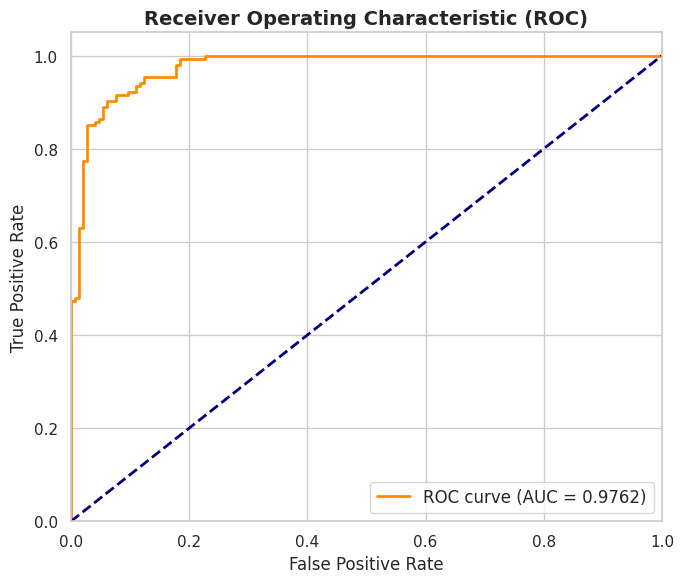

In [10]:
if len(class_names) > 2:
    lb = LabelBinarizer()
    lb.fit(y_true)
    y_true_bin = lb.transform(y_true)

    plt.figure(figsize=(7, 6))
    for i, class_name in enumerate(class_names):
        fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_scores[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f'ROC {class_name} (AUC = {roc_auc:.3f})')

    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=10)
    plt.tight_layout()
    plt.show()
else:
    # Binary ROC
    fpr, tpr, _ = roc_curve(y_true, y_scores[:, 1])
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=12)
    plt.ylabel('True Positive Rate', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=12)
    plt.tight_layout()
    plt.show()

## 6.5 Per Class Graph


In [ ]:
plt.figure(figsize=(8, 5))
class_f1s = [report[c]['f1-score'] for c in class_names]
sns.barplot(x=class_names, y=class_f1s, palette="viridis")
plt.title(f"F1-Score per Class - {model_name}", fontsize=14, fontweight='bold')
plt.ylabel('F1-Score', fontsize=12)
plt.xlabel('Class', fontsize=12)
plt.ylim([0.0, 1.05])
for i, v in enumerate(class_f1s):
    plt.text(i, v + 0.02, f"{v:.3f}", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()